In [9]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

# ---------------------------------------
# Cypher Queries: universell für jede DB
# ---------------------------------------
COUNT_NODES = """MATCH (n) RETURN count(n) AS nodes;"""
COUNT_EDGES = """MATCH ()-[r]->() RETURN count(r) AS edges;"""

def get_counts(db_name: str) -> dict:
    """Liefert die Anzahl aller Knoten und Kanten für eine Datenbank."""
    with driver.session(database=db_name) as session:
        nodes = session.run(COUNT_NODES).single()["nodes"]
        edges = session.run(COUNT_EDGES).single()["edges"]
    return {"database": db_name, "nodes": nodes, "edges": edges}


# ---------------------------------------
# Deine 4 Datenbanken
# ---------------------------------------
DBS = ["simplekg", "neo4j", "llmakg", "llmagraphtrkg"]

results = [get_counts(db) for db in DBS]

driver.close()

df = pd.DataFrame(results)

# Schönere Namen für die Thesis
rename_map = {
    "simplekg": "KG_Neo4j_Extractor_Version1",
    "neo4j": "KG_Neo4j_Extractor_Version2",
    "llmakg": "KG_LlamaIndex_Extractor",
    "llmagraphtrkg": "KG_Langchain_Extractor",
}
df["database"] = df["database"].replace(rename_map)

print(df)


                      database  nodes  edges
0  KG_Neo4j_Extractor_Version1   1157   1974
1  KG_Neo4j_Extractor_Version2    841   1252
2      KG_LlamaIndex_Extractor   1574   4472
3       KG_Langchain_Extractor    884   2487


In [10]:
df_long = df.melt(
    id_vars="database",
    value_vars=["nodes", "edges"],
    var_name="type",
    value_name="count",
)


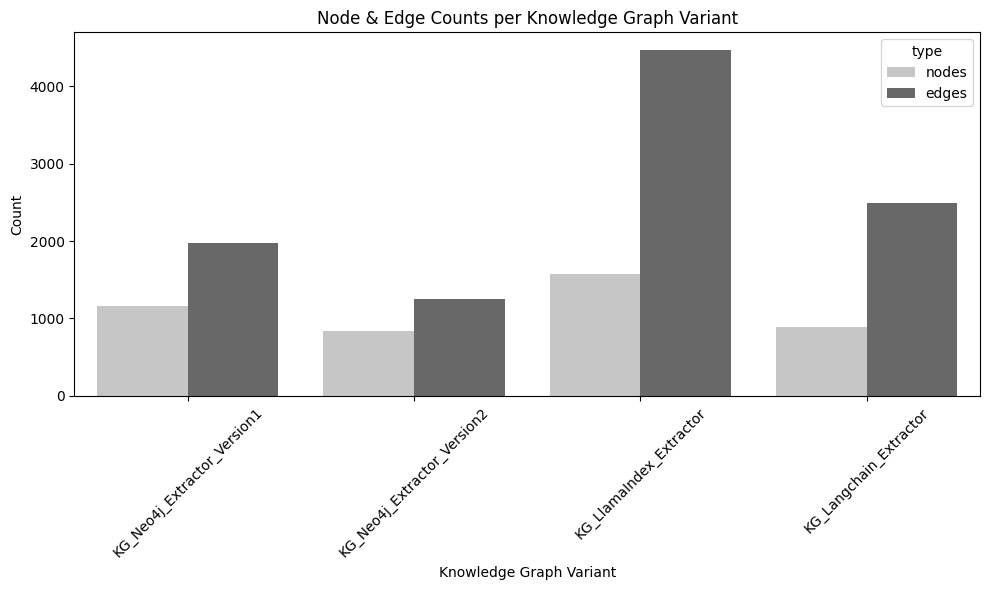

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Schriftfarbe überall auf Schwarz setzen ---
plt.rcParams['text.color'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_long,
    x="database",
    y="count",
    hue="type",
    palette="Greys"    # Grautöne für die Bars
)

plt.title("Node & Edge Counts per Knowledge Graph Variant")
plt.xlabel("Knowledge Graph Variant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
